In [1]:
import cirq
import numpy as np
import numpy.typing as npt
from cirq.experiments import TomographyResult

Creates a $|0\rangle_{L}$ for the Steane code from https://quantumcomputing.stackexchange.com/a/23346/362.

In [2]:
def encode(qubits: list[cirq.LineQubit]) -> cirq.Circuit:
    encoding_circuit = cirq.Circuit(
        cirq.H(qubits[0]),
        cirq.H(qubits[1]),
        cirq.H(qubits[3]),
        cirq.CX(qubits[0], qubits[2]),
        cirq.CX(qubits[3], qubits[5]),
        cirq.CX(qubits[1], qubits[6]),
        cirq.CX(qubits[0], qubits[4]),
        cirq.CX(qubits[3], qubits[6]),
        cirq.CX(qubits[1], qubits[5]),
        cirq.CX(qubits[0], qubits[6]),
        cirq.CX(qubits[1], qubits[2]),
        cirq.CX(qubits[3], qubits[4]),
    )
    return encoding_circuit

Gets the logical basis states from the physical measurements.

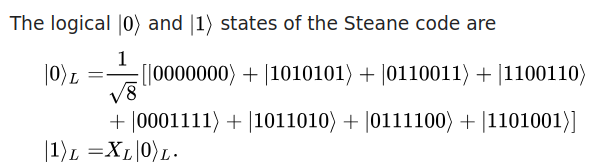

https://en.wikipedia.org/wiki/Steane_code

In [3]:
def physical_measurements_to_logical_measurements(measurements: npt.NDArray[np.float64]) -> int:
    ket_0 = [
        [0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 1, 1, 1, 1],
        [0, 1, 1, 0, 0, 1, 1],
        [0, 1, 1, 1, 1, 0, 0],
        [1, 0, 1, 0, 1, 0, 1],
        [1, 0, 1, 1, 0, 1, 0],
        [1, 1, 0, 0, 1, 1, 0],
        [1, 1, 0, 1, 0, 0, 1],
    ]
    # |1> is the opposite of |0>
    ket_1 = [[1 - bit for bit in state] for state in ket_0]
    list_measurements = list(measurements)
    if list_measurements in ket_0:
        return 0
    elif list_measurements in ket_1:
        return 1
    else:
        raise ValueError(
            f"Your logical state is outside the Steane encoding's subspace {measurements}"
        )
        

Simulates the circuits as physical circuits and transforms the physical measurements into logical measurements

In [4]:
def simulator(circuit: cirq.Circuit, repetitions: int) -> cirq.ResultDict:
    sim = cirq.Simulator()
    results = sim.run(circuit, repetitions=repetitions)
    new_result_dict = {}
    results_at_key = results.records["data_key"][:, -1, :]
    results_values = []
    for result in results_at_key:
        phys = physical_measurements_to_logical_measurements(result)
        results_values.append(phys)
    new_result_dict["data_key"] = np.array([results_values])
    results = cirq.ResultDict(params=cirq.ParamResolver({}), measurements=new_result_dict)
    return results

Gets the logical circuit as a physical circuit. Applies the physical `Rz` rotations and then measures the `X` and `Z` syndromes


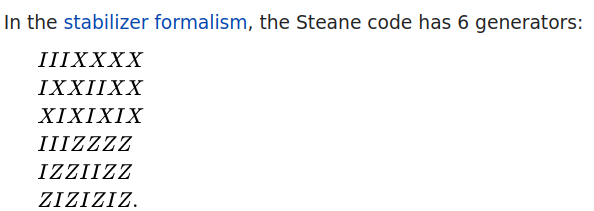

https://en.wikipedia.org/wiki/Steane_code

In [5]:
def logical_circuit(
    theta: float, data_qubits: list[cirq.LineQubit], ancilla_qubits: list[cirq.LineQubit]
) -> cirq.Circuit:
    logical_circuit = encode(data_qubits)
    logical_circuit.append(cirq.H.on_each(data_qubits))

    logical_circuit.append(cirq.rz(theta).on(data_qubits[0]))
    logical_circuit.append(cirq.rz(theta).on(data_qubits[1]))
    logical_circuit.append(cirq.rz(theta).on(data_qubits[2]))
    logical_circuit.append(cirq.rz(theta).on(data_qubits[3]))
    logical_circuit.append(cirq.rz(theta).on(data_qubits[4]))
    logical_circuit.append(cirq.rz(theta).on(data_qubits[5]))
    logical_circuit.append(cirq.rz(theta).on(data_qubits[6]))

    # First half of parity measurement
    logical_circuit.append(cirq.H.on_each(ancilla_qubits))

    # First generator
    logical_circuit.append(cirq.CX(ancilla_qubits[0], data_qubits[3]))
    logical_circuit.append(cirq.CX(ancilla_qubits[0], data_qubits[4]))
    logical_circuit.append(cirq.CX(ancilla_qubits[0], data_qubits[5]))
    logical_circuit.append(cirq.CX(ancilla_qubits[0], data_qubits[6]))

    # Second generator
    logical_circuit.append(cirq.CX(ancilla_qubits[1], data_qubits[1]))
    logical_circuit.append(cirq.CX(ancilla_qubits[1], data_qubits[2]))
    logical_circuit.append(cirq.CX(ancilla_qubits[1], data_qubits[5]))
    logical_circuit.append(cirq.CX(ancilla_qubits[1], data_qubits[6]))

    # Third generator
    logical_circuit.append(cirq.CX(ancilla_qubits[2], data_qubits[0]))
    logical_circuit.append(cirq.CX(ancilla_qubits[2], data_qubits[2]))
    logical_circuit.append(cirq.CX(ancilla_qubits[2], data_qubits[4]))
    logical_circuit.append(cirq.CX(ancilla_qubits[2], data_qubits[6]))

    # Fourth generator
    logical_circuit.append(cirq.CZ(ancilla_qubits[3], data_qubits[3]))
    logical_circuit.append(cirq.CZ(ancilla_qubits[3], data_qubits[4]))
    logical_circuit.append(cirq.CZ(ancilla_qubits[3], data_qubits[5]))
    logical_circuit.append(cirq.CZ(ancilla_qubits[3], data_qubits[6]))

    # Fifth generator
    logical_circuit.append(cirq.CZ(ancilla_qubits[4], data_qubits[1]))
    logical_circuit.append(cirq.CZ(ancilla_qubits[4], data_qubits[2]))
    logical_circuit.append(cirq.CZ(ancilla_qubits[4], data_qubits[5]))
    logical_circuit.append(cirq.CZ(ancilla_qubits[4], data_qubits[6]))

    # Sixth generator
    logical_circuit.append(cirq.CZ(ancilla_qubits[5], data_qubits[0]))
    logical_circuit.append(cirq.CZ(ancilla_qubits[5], data_qubits[2]))
    logical_circuit.append(cirq.CZ(ancilla_qubits[5], data_qubits[4]))
    logical_circuit.append(cirq.CZ(ancilla_qubits[5], data_qubits[6]))

    # Second half of parity measurement
    logical_circuit.append(cirq.H.on_each(ancilla_qubits))
    logical_circuit.append(cirq.measure(ancilla_qubits, key="ancilla_key"))
    return logical_circuit

Transversally applying a non-CLifford to a gateset that doesn't have fault-tolerant transversal non-Cliffords sometimes takes it out of the codespace. `PostSelectCodition` post selects on the syndromes being zero and also being in the logical code space of the code.

In [6]:
class PostSelectCodition(cirq.Condition):
    def __init__(self) -> None:
        pass

    @property
    def keys(self) -> tuple["cirq.MeasurementKey", ...]:
        return (cirq.MeasurementKey("ancilla_key"),)

    @property
    def qasm(self) -> None:
        raise ValueError("QASM is defined only for SympyConditions of type key == constant.")

    def replace_key(  # noqa: D102
        self,
        current: "cirq.MeasurementKey",
        replacement: "cirq.MeasurementKey",
    ) -> None:
        raise ValueError("Can't replace key")

    def resolve(self, classical_data: cirq.ClassicalDataStoreReader) -> bool:
        a_value = classical_data.records[cirq.MeasurementKey(name="ancilla_key")]
        b_value = classical_data.records[cirq.MeasurementKey(name="data_key")]
        logical_b_value = None

        try:
            logical_b_value = physical_measurements_to_logical_measurements(np.array(b_value[0]))
        except ValueError:
            pass
        if a_value == [(0, 0, 0, 0, 0, 0)] and logical_b_value is not None:
            return True
        return False

Appends basis measurements to the logical circuit.

In [7]:
def measure(
    cq: cirq.Circuit,
    measure_operations: list[list[cirq.Operation] | cirq.Operation],
    cond: PostSelectCodition,
) -> cirq.Circuit:
    circuit = cirq.Circuit(
        cirq.CircuitOperation(
            cirq.FrozenCircuit(cq, measure_operations),
            use_repetition_ids=False,
            repeat_until=cond,
        )
    )
    return circuit

[Single qubit state tomography](https://github.com/quantumlib/Cirq/blob/6d791fa8d1e25cad4fa543afe79e0e79e5175a90/cirq-core/cirq/experiments/qubit_characterizations.py#L612) on the Steane code.

In [8]:
def logical_tomography(
    cq: cirq.Circuit, data_qubits: list[cirq.LineQubit], repetitions: int
) -> TomographyResult:
    """Does logical tomography.
    :param cq:
    :param repetitions:
    :return: The tomography result.
    """
    key = "data_key"
    sympy_cond = PostSelectCodition()
    # Z measurement
    circuit_z = measure(cq, [cirq.measure(data_qubits, key=key)], sympy_cond)
    results = simulator(circuit_z, repetitions)
    rho_11 = np.mean(results.measurements[key])
    rho_00 = 1.0 - rho_11
    # X/2 measurement
    circuit_x = measure(
        cq,
        [
            cirq.H.on_each(data_qubits),
            cirq.S.on_each(data_qubits),
            cirq.H.on_each(data_qubits),
            cirq.measure(data_qubits, key=key),
        ],
        sympy_cond,
    )
    results = simulator(circuit_x, repetitions)
    rho_01_im = np.mean(results.measurements[key]) - 0.5
    # Y/2 measurement
    circuit_y = measure(
        cq,
        [
            cirq.H.on_each(data_qubits),
            cirq.Y.on_each(data_qubits),
            cirq.X.on_each(data_qubits),
            cirq.measure(data_qubits, key=key),
        ],
        sympy_cond,
    )
    results = simulator(circuit_y, repetitions)

    rho_01_re = 0.5 - np.mean(results.measurements[key])

    rho_01 = rho_01_re + 1j * rho_01_im
    rho_10 = np.conj(rho_01)
    rho = np.array([[rho_00, rho_01], [rho_10, rho_11]])

    return TomographyResult(rho)

[Fault Tolerant Non-Clifford State Preparation for Arbitrary Rotations](https://arxiv.org/abs/2303.17380) says that $\theta_L = 2\sin^{-1}\left(\frac{\sin^d(\theta/2)}{\sqrt{\cos^{2d}(\theta/2)+\sin^{2d}(\theta/2)}}\right)$

In [9]:
def theta_l_from_theta(theta: float) -> float:
    s = np.sin(theta / 2)
    c = np.cos(theta / 2)
    numerator = s**3
    denominator = np.sqrt(c**6 + s**6)
    value = numerator / denominator
    return 2 * np.arcsin(value)

In [16]:
def test_msd_clifford() -> None:
    r = 1000
    q = cirq.LineQubit(0)
    simulator = cirq.Simulator()
    theta = np.pi / 2
    data_qubits = cirq.LineQubit.range(0, 7)
    ancilla_qubits = cirq.LineQubit.range(7, 13)
    lq_circuit = logical_circuit(theta, data_qubits, ancilla_qubits)
    act_rho_1 = logical_tomography(lq_circuit, data_qubits, repetitions=r).data
    c = cirq.Circuit(cirq.H(q), cirq.rz(theta_l_from_theta(theta)).on(q))
    tar_rho_1 = cirq.experiments.single_qubit_state_tomography(simulator, q, c, r).data
    return np.allclose(act_rho_1, tar_rho_1, atol=1e-1)

In [18]:
test_msd_clifford()

True

In [19]:
def test_msd_non_clifford() -> None:
    r = 1000
    q = cirq.LineQubit(0)
    simulator = cirq.Simulator()
    theta = np.pi / 4
    data_qubits = cirq.LineQubit.range(0, 7)
    ancilla_qubits = cirq.LineQubit.range(7, 13)
    lq_circuit = logical_circuit(theta, data_qubits, ancilla_qubits)
    act_rho_1 = logical_tomography(lq_circuit, data_qubits, repetitions=r).data
    c = cirq.Circuit(cirq.H(q), cirq.rz(theta_l_from_theta(theta)).on(q))
    tar_rho_1 = cirq.experiments.single_qubit_state_tomography(simulator, q, c, r).data
    return np.allclose(act_rho_1, tar_rho_1, atol=1e-1)

In [20]:
test_msd_clifford()

True